In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
train = pd.read_csv('../data/processed/train_balanced.csv')
test = pd.read_csv('../data/processed/test.csv')

x_train, y_train = train['text'], train['label']
x_test, y_test = test['text'], test['label']

In [3]:
train.isnull().sum()

text     0
label    0
dtype: int64

In [4]:
train = train.dropna(subset=['text'])


In [5]:
train['label'].value_counts()

label
0    27697
1    27697
Name: count, dtype: int64

In [6]:
# Drop nulls from training and test sets
x_train = x_train.dropna()
y_train = y_train.loc[x_train.index]   # align labels after dropping

x_test = x_test.dropna()
y_test = y_test.loc[x_test.index]

# Now run TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)


In [7]:
def evaluate_model(model, x_train, y_train, x_test, y_test, model_name):
    print(f"💪Training {model_name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    print(f"\n=== ⌨️{model_name} ===")
    print('Accuracy: ', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["Fake (0)", "Real (1)"]))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(x_test)[:,1]
    else:
        y_proba = model.decision_function(x_test)
        
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')
    
    

In [8]:
models = [
    (LogisticRegression(max_iter=1000, class_weight='balanced'), "Logistic Regression"),
    (MultinomialNB(), "Multinomial Naive Bayes"),
    (LinearSVC( class_weight='balanced'), "Linear SVM"),
    (RandomForestClassifier( class_weight='balanced'), "Random Forest")
]

💪Training Logistic Regression

=== ⌨️Logistic Regression ===
Accuracy:  0.9432397959183674
              precision    recall  f1-score   support

    Fake (0)       0.96      0.94      0.95      6924
    Real (1)       0.93      0.95      0.94      5620

    accuracy                           0.94     12544
   macro avg       0.94      0.94      0.94     12544
weighted avg       0.94      0.94      0.94     12544



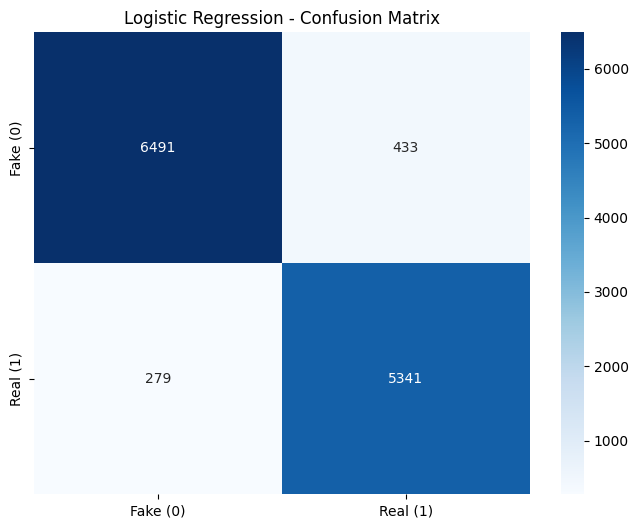

💪Training Multinomial Naive Bayes

=== ⌨️Multinomial Naive Bayes ===
Accuracy:  0.8505261479591837
              precision    recall  f1-score   support

    Fake (0)       0.89      0.83      0.86      6924
    Real (1)       0.81      0.88      0.84      5620

    accuracy                           0.85     12544
   macro avg       0.85      0.85      0.85     12544
weighted avg       0.85      0.85      0.85     12544



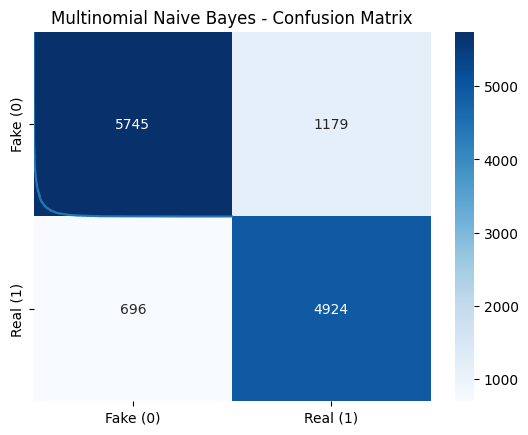

💪Training Linear SVM

=== ⌨️Linear SVM ===
Accuracy:  0.9501753826530612
              precision    recall  f1-score   support

    Fake (0)       0.96      0.95      0.95      6924
    Real (1)       0.94      0.95      0.94      5620

    accuracy                           0.95     12544
   macro avg       0.95      0.95      0.95     12544
weighted avg       0.95      0.95      0.95     12544



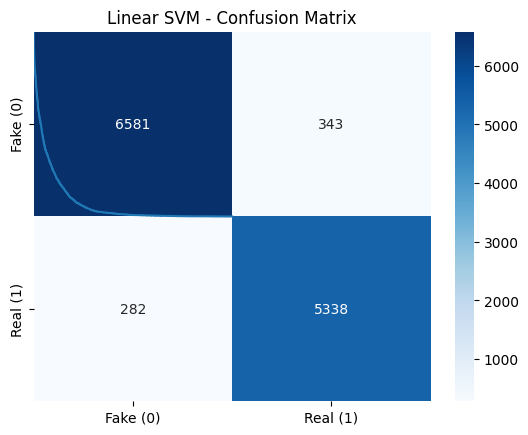

💪Training Random Forest


KeyboardInterrupt: 

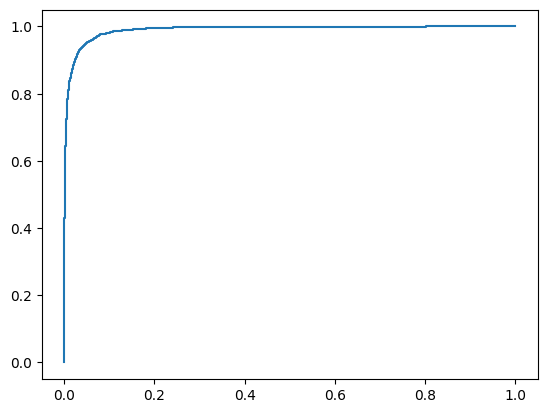

In [9]:
plt.figure(figsize=(8,6))
for model, name in models:
    evaluate_model(model, x_train_tfidf, y_train, x_test_tfidf, y_test, name)
    
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
user_input = input()

for model,name  in models:
    print(f'model: {model}')
    prediction = model.predict(vectorizer.transform([user_input]))[0]
    print(f'Prediction: {prediction}')
    

model: LogisticRegression(class_weight='balanced', max_iter=1000)
Prediction: 1
model: MultinomialNB()
Prediction: 1
model: LinearSVC(class_weight='balanced')
Prediction: 1
model: RandomForestClassifier(class_weight='balanced')
Prediction: 1
